
## 留意事項
* このnotebookは学習・検証を目的とした教育資料として公開しており、投資助言または投資勧誘を目的とするものではありません。
* 本notebookの著作権は作成者である[ほへとさん](https://x.com/i_love_profit)に帰属します。
* 公開者となるビットバンク株式会社は本notebookの内容の監修・保証（正確性・完全性・安全性）を行いません。
* 実行・利用は、必ず利用者自身の判断と責任で行ってください。

# Vol.01: データ取得とクレンジング
**暗号資産データ分析入門シリーズ**

---

**テーマ**: 分析の第一歩。信頼できるデータを手に入れる

### なぜデータ取得とクレンジングが「最も重要」なのか

データ分析の世界には **"Garbage In, Garbage Out"**（ゴミを入れればゴミが出てくる）という格言があります。どれほど洗練されたモデルを構築しても、どれほど巧みな戦略を設計しても、**入力データが汚れていれば、出力される結果はすべて信用できません**。

これは金融データ分析において特に深刻です。

- 欠損した1本の足が、移動平均やRSIの計算を狂わせる
- 重複データが、リターンをゼロに潰し、統計量を歪める
- 異常値1つが、バックテストの累積PnLを大きく左右する
- タイムスタンプのずれ1つが、リードラグ分析の結論を反転させる

**こうした問題は、分析の下流で「なんとなくおかしい結果」として現れますが、原因の特定は極めて困難です。** データの問題は静かに忍び込み、分析者が気づかないまま誤った意思決定を導きます。

### データ作業に最も時間を割くべき理由

実務のデータ分析プロジェクトでは、全体の作業時間の **60〜80%** がデータの取得・探索・クレンジングに費やされると言われています。これは非効率なのではなく、**そうあるべき**なのです。

```
典型的なデータ分析プロジェクトの時間配分:

  データ取得・探索・クレンジング  ████████████████████████  60-80%
  分析・モデル構築              ██████                    15-25%
  結果の解釈・報告              ███                        5-15%
```

初心者ほど、華やかな「戦略構築」や「モデル学習」に時間をかけたがります。しかし経験を積んだアナリストやクオンツほど、**データの品質確認に執拗なまでの時間をかけます**。なぜなら、クリーンなデータさえ手に入れば、分析や戦略構築は驚くほどスムーズに進むことを知っているからです。

逆に、データの問題を放置したまま先に進むと、後工程で原因不明のバグや再現不能な結果に悩まされ、結局はデータまで遡って調査するはめになります。**最初に時間をかけるか、後で倍の時間をかけるか** — 答えは明白です。

### このnotebookの位置づけ

このnotebookは、シリーズ全10本の **最も重要な土台** です。ここで学ぶデータ取得とクレンジングの手順は、Vol.02以降のすべての分析の前提となります。地味な作業に見えるかもしれませんが、**この工程の丁寧さが、最終的な分析結果の信頼性を決定します**。

### このnotebookで学ぶこと

1. **データ取得** — Binance REST APIからOHLCVデータを取得する
2. **DataFrameの基本操作** — 型変換、インデックス設定、ソートなど
3. **重複データの処理** — 重複したデータを見つけて除去する
4. **欠損値の処理** — 抜けているデータを見つけて適切に補完する
5. **リターンの計算** — 価格データから収益率を計算する
6. **異常値の処理** — 暗号資産特有のファットテール分布を考慮し、ドメイン知識に基づいて異常を検出する
7. **クレンジング前後の比較** — データ品質の改善を可視化して確認する

## 1. 環境準備

必要なライブラリをインストール・インポートします。

| ライブラリ | 用途 |
|---|---|
| requests | HTTP通信（Binance REST API呼び出し） |
| pandas | 表形式データの操作 |
| numpy | 数値計算 |
| matplotlib | グラフ描画 |
| japanize_matplotlib | matplotlibの日本語表示対応 |

In [ ]:
# 必要なライブラリのインストール
!pip install requests pandas numpy matplotlib japanize-matplotlib -q

In [ ]:
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import japanize_matplotlib
import time

# matplotlib表示設定
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['figure.dpi'] = 100

print("ライブラリの読み込み完了")
print(f"pandas version: {pd.__version__}")

ライブラリの読み込み完了
pandas version: 2.2.3


## 2. Binanceからのデータ取得

### OHLCVデータとは？

OHLCVは、一定期間の価格情報をまとめたデータ形式です。

| 項目 | 意味 | 説明 |
|------|------|------|
| **O**pen | 始値 | その期間の最初の取引価格 |
| **H**igh | 高値 | その期間の最も高い取引価格 |
| **L**ow | 安値 | その期間の最も安い取引価格 |
| **C**lose | 終値 | その期間の最後の取引価格 |
| **V**olume | 出来高 | その期間の取引量 |

### Binance REST API

Binanceは暗号資産の取引データを公開REST APIで提供しています。
OHLCVデータは以下のエンドポイントから取得できます（APIキー不要）。

```
GET https://api.binance.com/api/v3/klines
```

| パラメータ | 説明 |
|------------|------|
| symbol | 銘柄（例: BTCUSDT） |
| interval | 時間足（例: 1h, 5m, 1d） |
| startTime | 開始タイムスタンプ（ミリ秒） |
| endTime | 終了タイムスタンプ（ミリ秒） |
| limit | 取得本数（最大1000） |

In [ ]:
# 取得設定
symbol = 'BTCUSDT'          # 銘柄: ビットコイン / テザー
timeframe = '1h'             # 時間足: 1時間
since_date = '2024-01-01'   # 開始日
until_date = '2025-01-01'   # 終了日

print(f"取得対象: {symbol}")
print(f"時間足:   {timeframe}")
print(f"期間:     {since_date} 〜 {until_date}")

取得対象: BTCUSDT
時間足:   1h
期間:     2024-01-01 〜 2025-01-01


### ページネーションによるデータ取得

Binance APIは一度に取得できるデータ数に上限があります（最大1,000本）。
1年間の1時間足データは約8,760本あるため、**ページネーション**（繰り返し取得）が必要です。

以下の関数は、開始位置をずらしながらAPIを繰り返し呼び出し、全データを取得します。

In [ ]:
BINANCE_API_URL = "https://api.binance.com/api/v3/klines"

def fetch_ohlcv(symbol, interval, start_date, end_date, limit=1000):
    """
    Binance REST API から OHLCV データを取得する。

    Parameters
    ----------
    symbol : str     — 銘柄（例: 'BTCUSDT'）
    interval : str   — 時間足（例: '1h', '5m', '1d'）
    start_date : str — 開始日（例: '2024-01-01'）
    end_date : str   — 終了日（例: '2025-01-01'）※この日は含まない
    limit : int      — 1回のリクエストあたりの取得本数（最大1000）

    Returns
    -------
    pd.DataFrame — columns: [open, high, low, close, volume], index: timestamp (UTC)
    """
    start_ts = int(pd.Timestamp(start_date, tz="UTC").timestamp() * 1000)
    end_ts = int(pd.Timestamp(end_date, tz="UTC").timestamp() * 1000)

    all_data = []
    current_ts = start_ts

    while current_ts < end_ts:
        params = {
            "symbol": symbol,
            "interval": interval,
            "startTime": current_ts,
            "endTime": end_ts - 1,  # endTime は inclusive なので -1
            "limit": limit,
        }
        resp = requests.get(BINANCE_API_URL, params=params, timeout=30)
        resp.raise_for_status()
        data = resp.json()

        if not data:
            break

        all_data.extend(data)
        current_ts = data[-1][0] + 1  # 最後のレコードの次から再開
        time.sleep(0.2)  # レートリミット遵守（200ms間隔）

    if not all_data:
        return pd.DataFrame(columns=["open", "high", "low", "close", "volume"])

    df = pd.DataFrame(all_data, columns=[
        "timestamp", "open", "high", "low", "close", "volume",
        "_close_time", "_quote_vol", "_trades", "_taker_buy_vol",
        "_taker_buy_quote", "_ignore",
    ])

    df["timestamp"] = pd.to_datetime(df["timestamp"], unit="ms", utc=True)
    for col in ["open", "high", "low", "close", "volume"]:
        df[col] = df[col].astype(float)

    df = df[["timestamp", "open", "high", "low", "close", "volume"]]
    df = df.set_index("timestamp").sort_index()
    df = df[~df.index.duplicated(keep="first")]

    return df

# データを取得
print("データ取得中...")
df_1h = fetch_ohlcv(symbol, timeframe, since_date, until_date)
print(f"取得完了: {len(df_1h):,} 本")

データ取得中...


取得完了: 8,784 本


## 3. DataFrameの基本操作

`fetch_ohlcv()` 関数は、取得したデータをpandasの **DataFrame** に変換して返します。
ここでは、DataFrameの基本的な確認方法を見ていきましょう。

In [ ]:
# DataFrameの確認
# fetch_ohlcv() により以下の処理が既に完了しています:
#   - タイムスタンプ（ミリ秒の整数）→ datetime型に変換
#   - timestamp をインデックスに設定
#   - 時系列順にソート
#   - 重複行の除去

print(f"データ形状: {df_1h.shape}  （行数 × 列数）")
print(f"期間: {df_1h.index.min()} 〜 {df_1h.index.max()}")
print(f"\nデータ型:")
print(df_1h.dtypes)
print(f"\n--- 先頭5行 ---")
df_1h.head()

データ形状: (8784, 5)  （行数 × 列数）
期間: 2024-01-01 00:00:00+00:00 〜 2024-12-31 23:00:00+00:00

データ型:
open      float64
high      float64
low       float64
close     float64
volume    float64
dtype: object

--- 先頭5行 ---


,open,high,low,close,volume
timestamp,,,,,
2024-01-01 00:00:00+00:00,42283.58,42554.57,42261.02,42475.23,1271.68108
2024-01-01 01:00:00+00:00,42475.23,42775.00,42431.65,42613.56,1196.37856
2024-01-01 02:00:00+00:00,42613.57,42638.41,42500.00,42581.10,685.21980
2024-01-01 03:00:00+00:00,42581.09,42586.64,42230.08,42330.49,794.80391
2024-01-01 04:00:00+00:00,42330.50,42399.99,42209.46,42399.99,715.41760


In [ ]:
# 基本統計量の確認
# count（件数）、mean（平均）、std（標準偏差）、min/max、四分位数が一覧できる
df_1h.describe()

,open,high,low,close,volume
count,8784.000000,8784.000000,8784.000000,8784.000000,8784.000000
mean,65893.115044,66140.217911,65634.169937,65898.952048,1472.121149
std,14678.547431,14737.092246,14617.314323,14679.355540,1484.764525
min,38767.750000,38900.000000,38555.000000,38767.740000,92.165510
25%,59012.757500,59246.282500,58741.000000,59013.122500,622.963705
50%,64202.315000,64412.385000,63968.120000,64203.095000,1014.774035
75%,69042.632500,69265.050000,68800.387500,69044.215000,1760.258963
max,108258.380000,108353.000000,107130.000000,108258.390000,23219.736890


**ポイント**
- `timestamp` をインデックスに設定すると、期間指定（`df_1h['2024-06']`）やリサンプリング（`.resample('1D')`）が簡単になります
- `describe()` でデータの全体像を素早く把握できます。min/max に明らかにおかしな値がないかチェックしましょう

In [ ]:
# クレンジング前のデータをコピーしておく（後で比較に使う）
df_raw = df_1h.copy()
print(f"クレンジング前データを保存: {len(df_raw)} 行")

クレンジング前データを保存: 8784 行


## 4. 重複データの検出と除去

APIからページネーションで取得する際、境界部分で同じデータが重複して含まれることがあります。
重複があると、統計量の計算やリターンの算出が正しくできなくなるため、最初に除去します。

In [ ]:
# インデックス（タイムスタンプ）の重複を確認
n_duplicates = df_1h.index.duplicated().sum()
print(f"重複行の数: {n_duplicates}")

if n_duplicates > 0:
    # 重複している行を確認
    dup_mask = df_1h.index.duplicated(keep=False)
    print("\n重複している行の例:")
    display(df_1h[dup_mask].head(10))

    # 重複を除去（最初の出現を残す）
    df_1h = df_1h[~df_1h.index.duplicated(keep='first')]
    print(f"除去後のデータ数: {len(df_1h)}")
else:
    print("→ 重複行はありませんでした")

重複行の数: 0
→ 重複行はありませんでした


## 5. 欠損値の検出と補完

1時間足データの場合、各行の間隔は正確に1時間であるべきです。
取引所のメンテナンスやAPI障害などにより、一部の時間帯のデータが抜けていることがあります。

### 検出方法
「期待される全タイムスタンプ」のインデックスを作り、実データと比較することで抜けを見つけます。

In [ ]:
# 期待される時間インデックスを生成（要求期間全体をカバー）
# ※ データの最小/最大ではなく、取得を要求した期間で生成することで端の欠損も検出できる
expected_index = pd.date_range(
    start=pd.Timestamp(since_date, tz='UTC'),
    end=pd.Timestamp(until_date, tz='UTC') - pd.Timedelta('1h'),  # until_date は含まない
    freq='1h'
)

# 欠損しているタイムスタンプを検出
missing_timestamps = expected_index.difference(df_1h.index)
n_missing = len(missing_timestamps)

print(f"期待されるデータ数: {len(expected_index):,}")
print(f"実際のデータ数:     {len(df_1h):,}")
print(f"欠損タイムスタンプ: {n_missing}")

if n_missing > 0 and n_missing <= 20:
    print("\n欠損している時間帯:")
    for ts in missing_timestamps:
        print(f"  {ts}")
elif n_missing > 20:
    print(f"\n欠損している時間帯（先頭20件）:")
    for ts in missing_timestamps[:20]:
        print(f"  {ts}")

期待されるデータ数: 8,784
実際のデータ数:     8,784
欠損タイムスタンプ: 0


In [ ]:
# 完全な時間インデックスでリインデックス（欠損箇所は NaN になる）
df_1h = df_1h.reindex(expected_index)
df_1h.index.name = 'timestamp'

# NaN の数を確認
print("列ごとの欠損値の数:")
print(df_1h.isnull().sum())

列ごとの欠損値の数:
open      0
high      0
low       0
close     0
volume    0
dtype: int64


In [ ]:
# 列ごとに適切な補完方法を適用する
# - 価格列（open, high, low, close）: 前方補完（直前の価格が継続したと解釈）
# - 出来高（volume）: 0で補完（取引がなかった＝出来高ゼロと解釈）
price_cols = ['open', 'high', 'low', 'close']
df_1h[price_cols] = df_1h[price_cols].ffill()
df_1h['volume'] = df_1h['volume'].fillna(0)

print("補完後の欠損値の数:")
print(df_1h.isnull().sum())
print(f"\n補完後のデータ数: {len(df_1h):,}")

補完後の欠損値の数:
open      0
high      0
low       0
close     0
volume    0
dtype: int64

補完後のデータ数: 8,784


### 補完方法の比較

| 方法 | 説明 | 向き不向き |
|------|------|-----------|
| **前方補完（ffill）** | 直前の値で埋める | ✅ 価格データに最適。未来の情報を使わない |
| 後方補完（bfill） | 次の値で埋める | ⚠️ 未来のデータを使うためリーク（情報漏洩）の危険 |
| 線形補間 | 前後の値から線形に補間 | ⚠️ 後方の値（未来）を参照する |
| ゼロ補完 | 0で埋める | ✅ 出来高に適切（取引なし＝0） |
| 定数補完 | 固定値で埋める | ❌ 価格データには不適切 |

**重要**: 
- 金融データ分析では **リーク（未来のデータの混入）を避ける** ことが鉄則です。価格列には前方補完が推奨されます
- **列ごとに補完方法を変える** のが正しいアプローチです。上のコードでは価格列はffill、出来高は0で補完しています

## 6. リターン（収益率）の計算

リターンは「価格がどれだけ変化したか」を表す、データ分析の最も基本的な指標です。

### 2種類のリターン

リターンの計算方法には **単純リターン** と **対数リターン** の2種類があります。

| 種類 | 計算式 | pandas |
|------|--------|--------|
| 単純リターン | $r_t = \frac{P_t - P_{t-1}}{P_{t-1}}$ | `df["close"].pct_change()` |
| 対数リターン | $r_t^{log} = \ln\frac{P_t}{P_{t-1}}$ | `np.log(df["close"] / df["close"].shift(1))` |

小さな変動（±数%程度）では両者はほぼ一致しますが、大きな変動では差が出ます。

| 値 | 解釈 |
|----|------|
| +0.01 | 1%の上昇 |
| -0.02 | 2%の下落 |
| 0 | 変化なし |

### このシリーズでは単純リターンを使う

このシリーズでは **単純リターン（`pct_change()`）** を使用します。理由は以下のとおりです。

1. **直感的に分かりやすい**: +0.01 = 1%上昇。対数リターンはスケールの解釈にひと手間かかる
2. **下流タスクとの相性が良い**: 相関分析、回帰の目的変数、5分位分析など、そのまま使える
3. **実務でも標準的**: 他のデータソースやレポートとの比較が容易

### 累積リターンと cumsum

リターンの累積は **cumsum()** で計算します。

```python
cumulative_return = df["ret"].cumsum()
```

#### 正確な累積リターンの計算方法

数学的に正確な累積リターンを求めるには、以下のいずれかを使います。

| 方法 | 計算 |
|------|------|
| 単純リターン → cumprod | `(1 + ret).cumprod() - 1` |
| 対数リターン → cumsum → exp | `np.exp(log_ret.cumsum()) - 1` |

この2つは等価です。いずれも複利効果を正しく反映します。

#### なぜ戦略検証では cumsum を使うのか

正確な計算があるにもかかわらず、**戦略の探索・検証段階では意図的に単純リターンの cumsum を使います**。

| 方式 | 特徴 | 用途 |
|------|------|------|
| 単純リターン + cumsum | フラットな物差し。時期を問わず一様に比較できる。コードもシンプル | 戦略探索・指標評価 |
| 単純リターン + cumprod | 複利効果で後半ほどスケールが膨らみ、時期間の比較が困難 | 最終的な損益シミュレーション |

cumprod では後半の値動きが複利で増幅されるため、「初期にエッジがあったか、後半にあったか」の比較が難しくなります。
cumsum なら全期間を通じてフラットな基準で評価でき、**どの時期に指標が効いていたかが一目で分かります**。

1時間足や日足レベルの小さな変動（±数%）では cumsum と cumprod の差はごくわずかです。
最終的に戦略を実運用する際には、証拠金ベースでポジションサイズを計算し、正確な損益シミュレーションを行います。

In [ ]:
# リターンの計算
df_1h['ret'] = df_1h['close'].pct_change()

# 基本統計量の確認
print("リターンの基本統計量:")
print(df_1h['ret'].describe().to_string())

print(f"\n平均リターン: {df_1h['ret'].mean():.6f}")
print(f"標準偏差:     {df_1h['ret'].std():.6f}")
print(f"最小値:       {df_1h['ret'].min():.6f}")
print(f"最大値:       {df_1h['ret'].max():.6f}")

リターンの基本統計量:
count    8783.000000
mean        0.000106
std         0.005617
min        -0.045873
25%        -0.002277
50%         0.000090
75%         0.002566
max         0.043109

平均リターン: 0.000106
標準偏差:     0.005617
最小値:       -0.045873
最大値:       0.043109


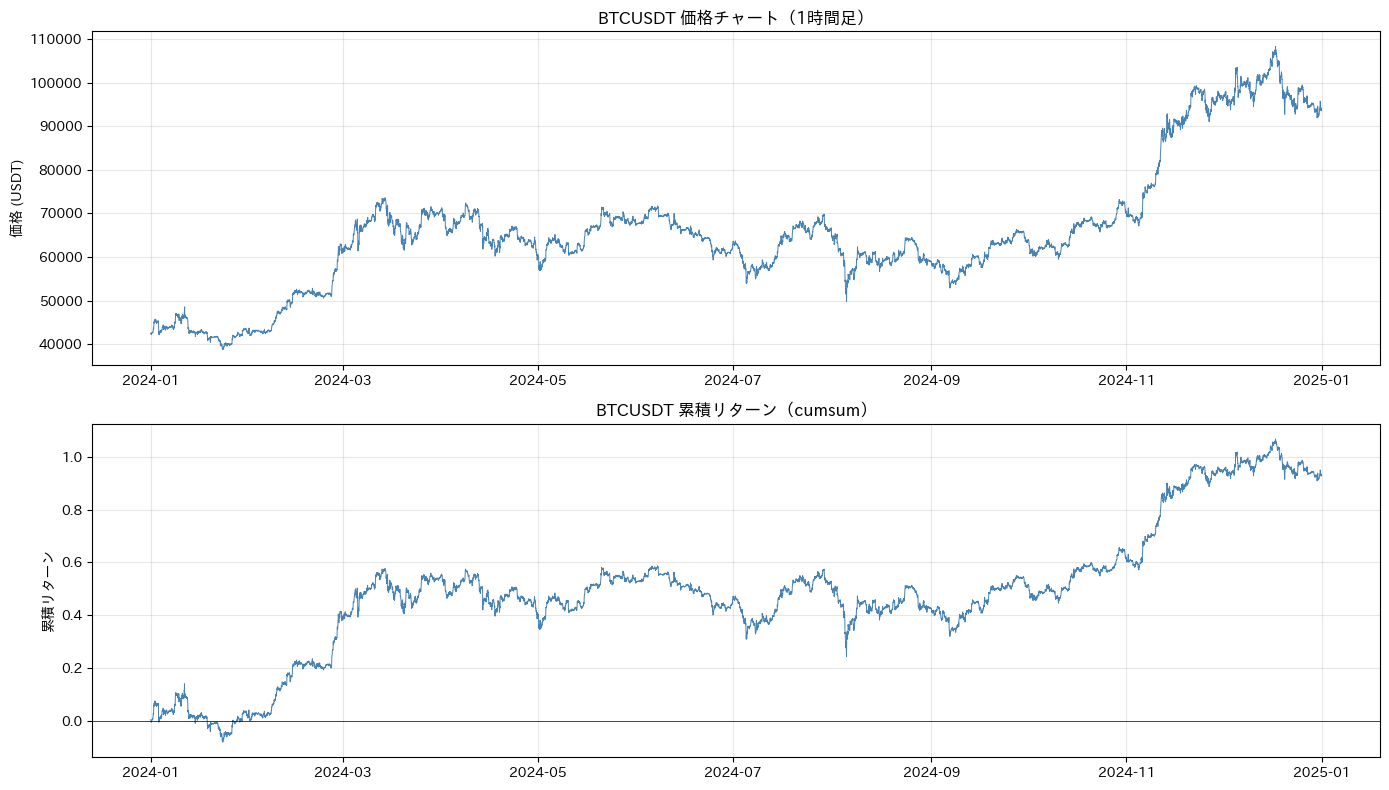

最終累積リターン: 0.9285 (92.9%)
  ※ cumsumは近似値です。cumprodによる正確な累積: 120.3%


In [ ]:
# 累積リターンのプロット
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# 上段: 価格チャート
axes[0].plot(df_1h.index, df_1h['close'], color='steelblue', linewidth=0.7)
axes[0].set_title(f'{symbol} 価格チャート（1時間足）')
axes[0].set_ylabel('価格 (USDT)')
axes[0].grid(True, alpha=0.3)

# 下段: 累積リターン（cumsum）
cumulative_return = df_1h['ret'].cumsum()
axes[1].plot(df_1h.index, cumulative_return, color='steelblue', linewidth=0.7)
axes[1].set_title(f'{symbol} 累積リターン（cumsum）')
axes[1].set_ylabel('累積リターン')
axes[1].axhline(y=0, color='black', linewidth=0.5)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"最終累積リターン: {cumulative_return.iloc[-1]:.4f} ({cumulative_return.iloc[-1]*100:.1f}%)")
print(f"  ※ cumsumは近似値です。cumprodによる正確な累積: {((1 + df_1h['ret']).cumprod().iloc[-1] - 1)*100:.1f}%")

## 7. 異常値の検出と処理

### 暗号資産データにおける「異常値」の考え方

一般的なデータ分析では、Zスコア法（|Z| > 3 を外れ値とみなす）やIQR法がよく使われます。
しかし、**暗号資産市場ではこれらの手法をそのまま適用すべきではありません**。

理由は明確です。暗号資産の価格変動は**ファットテール分布**（裾が厚い分布）に従っており、
数%の急変動は日常的に発生します。これらは**市場の正常な振る舞い**であり、エラーではありません。

| ケース | 異常値か？ | 処理 |
|--------|-----------|------|
| 1時間で -5% の急落 | **いいえ**。暗号資産では日常的 | そのまま残す |
| 大きなニュースで +10% の急騰 | **いいえ**。ファンダメンタルに基づく動き | そのまま残す |
| 価格が突然 0 や 1 になる | **はい**。取引所のバグ・API障害 | 除去または補正 |
| 前の足から 99% 以上の暴落 | **はい**。データ欠損やフラッシュクラッシュの可能性 | 調査して判断 |
| 1本だけ出来高がゼロで価格が飛ぶ | **はい**。データ欠損の兆候 | 前方補完（ffill） |

**ポイント**: 本当に除去すべきは「市場の急変動」ではなく、「取引所の異常やデータ欠損に起因するノイズ」です。
統計的な閾値で機械的にフィルタリングするのではなく、**ドメイン知識に基づいて判断**します。

### 検出アプローチ

ここでは、以下の3つの観点でデータ異常を検出します。

1. **価格の妥当性チェック**: 価格がゼロや負、極端に小さい値になっていないか
2. **変動率の常識チェック**: 1本の足で 50% 以上の変動（取引所障害レベル）がないか
3. **出来高の消失チェック**: 出来高がゼロの足が連続していないか（取引停止の兆候）

In [ ]:
# --- チェック1: 価格の妥当性 ---
# 価格がゼロ、負、または極端に小さい値（例: 1ドル未満）になっていないか
price_cols = ['open', 'high', 'low', 'close']

print("=== 価格の妥当性チェック ===")
for col in price_cols:
    invalid = df_1h[df_1h[col] <= 0]
    suspicious = df_1h[df_1h[col] < 100]  # BTCが100ドル未満は明らかに異常
    print(f"  {col}: ゼロ以下={len(invalid)}件, 100ドル未満={len(suspicious)}件")

# OHLC整合性: high >= low であるべき
inconsistent = df_1h[df_1h['high'] < df_1h['low']]
print(f"\n  high < low（OHLC不整合）: {len(inconsistent)} 件")

if len(inconsistent) > 0:
    print("\n不整合のある行:")
    print(inconsistent[['open', 'high', 'low', 'close']].head())
else:
    print("→ 価格データに異常なし")

=== 価格の妥当性チェック ===
  open: ゼロ以下=0件, 100ドル未満=0件
  high: ゼロ以下=0件, 100ドル未満=0件
  low: ゼロ以下=0件, 100ドル未満=0件
  close: ゼロ以下=0件, 100ドル未満=0件

  high < low（OHLC不整合）: 0 件
→ 価格データに異常なし


### チェック2: 変動率の常識チェック

1本の足で 50% 以上の変動が起きている場合、取引所の障害やデータ欠損の可能性が高いです。
暗号資産は変動が激しいとはいえ、1時間足で 50% の変動は通常あり得ません。

**なぜ |Z| > 3 ではなく 50% なのか？**

- BTCの1時間足では、±3〜5% 程度の変動はニュース・清算連鎖などで普通に起こる
- Zスコア法（|Z| > 3）を使うと、こうした「市場の正常なテールイベント」まで外れ値として検出してしまう
- 本当に除外すべきは「市場では起こり得ないレベルの変動」＝データ異常のサイン

In [ ]:
# --- チェック2: 変動率の常識チェック ---
# 1本の足で50%以上の変動は取引所障害レベル
extreme_threshold = 0.50  # 50%

extreme_moves = df_1h[df_1h['ret'].abs() > extreme_threshold].dropna(subset=['ret'])

print(f"=== 変動率の常識チェック（閾値: ±{extreme_threshold*100:.0f}%）===")
print(f"  該当件数: {len(extreme_moves)} 件 / {len(df_1h):,} 件")

if len(extreme_moves) > 0:
    print("\n異常な変動が検出されました:")
    print(extreme_moves[['close', 'volume', 'ret']].to_string())
    print("\n→ これらの行はデータ異常の可能性が高いため、調査・除去を検討すべきです")
else:
    print("→ 取引所障害レベルの極端な変動はなし")

# 参考: 大きな変動のTOP10を表示（異常でなくても特徴的な動き）
print(f"\n--- 参考: 変動率の大きい足 TOP10 ---")
top10 = df_1h['ret'].dropna().abs().nlargest(10)
for ts, val in top10.items():
    direction = "↑" if df_1h.loc[ts, 'ret'] > 0 else "↓"
    print(f"  {ts}  {direction} {val*100:+.2f}%  (終値: {df_1h.loc[ts, 'close']:,.0f})")

print("\n※ これらは市場の急変動であり、データ異常ではないためそのまま残します")

=== 変動率の常識チェック（閾値: ±50%）===
  該当件数: 0 件 / 8,784 件
→ 取引所障害レベルの極端な変動はなし

--- 参考: 変動率の大きい足 TOP10 ---
  2024-04-13 20:00:00+00:00  ↓ +4.59%  (終値: 61,816)
  2024-08-05 13:00:00+00:00  ↑ +4.31%  (終値: 51,951)
  2024-04-19 06:00:00+00:00  ↑ +4.11%  (終値: 64,624)
  2024-08-05 14:00:00+00:00  ↑ +4.06%  (終値: 54,062)
  2024-03-05 19:00:00+00:00  ↓ +4.03%  (終値: 61,411)
  2024-08-06 00:00:00+00:00  ↑ +3.74%  (終値: 56,038)
  2024-08-12 14:00:00+00:00  ↑ +3.68%  (終値: 60,300)
  2024-01-11 15:00:00+00:00  ↓ +3.68%  (終値: 46,784)
  2024-03-15 02:00:00+00:00  ↓ +3.62%  (終値: 69,035)
  2024-04-13 19:00:00+00:00  ↓ +3.53%  (終値: 64,788)

※ これらは市場の急変動であり、データ異常ではないためそのまま残します


In [ ]:
# --- チェック3: 出来高の消失チェック ---
# 出来高がゼロの足が連続している場合、取引停止やデータ欠損の兆候

zero_volume = df_1h[df_1h['volume'] == 0]
print(f"=== 出来高ゼロのチェック ===")
print(f"  出来高ゼロの足: {len(zero_volume)} 件 / {len(df_1h):,} 件")

if len(zero_volume) > 0:
    # 連続ゼロの検出
    is_zero = (df_1h['volume'] == 0).astype(int)
    consecutive = is_zero.groupby((is_zero != is_zero.shift()).cumsum()).cumsum()
    max_consecutive = consecutive.max()
    print(f"  最大連続ゼロ: {max_consecutive} 本")
    if max_consecutive >= 3:
        print("  ⚠️ 3本以上の連続ゼロ出来高があります。取引停止の可能性があるため要調査")
    print(f"\n出来高ゼロの行:")
    print(zero_volume[['close', 'volume']].head(10).to_string())
else:
    print("→ 出来高ゼロの足はなし（正常）")

# 出来高の分布を確認（極端に小さい出来高もチェック）
vol_percentile_1 = df_1h['volume'].quantile(0.01)
print(f"\n出来高の1パーセンタイル: {vol_percentile_1:.2f} BTC")
print(f"出来高の中央値:         {df_1h['volume'].median():.2f} BTC")

=== 出来高ゼロのチェック ===
  出来高ゼロの足: 0 件 / 8,784 件
→ 出来高ゼロの足はなし（正常）

出来高の1パーセンタイル: 199.50 BTC
出来高の中央値:         1014.77 BTC


### 異常値の処理方針

チェックの結果に基づき、以下のように処理します。

| 検出された異常 | 処理方法 |
|---------------|---------|
| 価格がゼロ・負・極端に小さい | その行を削除し、前方補完（ffill） |
| 1本で50%以上の変動 | 前後の足を確認し、取引所障害なら削除してffill |
| 出来高ゼロが3本以上連続 | 取引停止区間として除外を検討 |
| 上記に該当しない大きな変動 | **そのまま残す**（市場の正常な動き） |

**重要な原則**: 迷ったら残す。データを安易に削除すると、テールリスクを過小評価することになり、
バックテストで本来は損失が出るはずの局面を見逃すことにつながります。

In [ ]:
# --- 異常データの除去（該当があれば） ---

n_before = len(df_1h)

# 1. 価格がゼロ以下の行を除去
price_invalid = (df_1h[['open', 'high', 'low', 'close']] <= 0).any(axis=1)
n_price_invalid = price_invalid.sum()

# 2. 1本で50%以上の変動を除去
extreme_ret = df_1h['ret'].abs() > 0.50
n_extreme = extreme_ret.sum()

# 3. OHLC不整合を除去
ohlc_invalid = df_1h['high'] < df_1h['low']
n_ohlc_invalid = ohlc_invalid.sum()

# 該当行を除去
anomaly_mask = price_invalid | extreme_ret.fillna(False) | ohlc_invalid
n_removed = anomaly_mask.sum()

if n_removed > 0:
    print(f"除去対象: {n_removed} 件")
    print(f"  - 価格異常: {n_price_invalid} 件")
    print(f"  - 極端な変動: {n_extreme} 件")
    print(f"  - OHLC不整合: {n_ohlc_invalid} 件")

    # 異常行をNaNにして前方補完
    df_1h.loc[anomaly_mask, ['open', 'high', 'low', 'close', 'volume']] = np.nan
    df_1h[['open', 'high', 'low', 'close']] = df_1h[['open', 'high', 'low', 'close']].ffill()
    df_1h['volume'] = df_1h['volume'].fillna(0)

    # リターンを再計算
    df_1h['ret'] = df_1h['close'].pct_change()
    print(f"\n除去後のデータ数: {len(df_1h):,}（行数は変わらず、値を前方補完で置換）")
else:
    print("除去対象のデータ異常はありませんでした。")
    print("→ Binanceの主要ペア（BTC/USDT）は高品質なデータが提供されています。")
    print("   ただし、マイナー銘柄や他の取引所では異常が見つかることがあるため、")
    print("   このチェック手順自体は常に実行すべきです。")

除去対象のデータ異常はありませんでした。
→ Binanceの主要ペア（BTC/USDT）は高品質なデータが提供されています。
   ただし、マイナー銘柄や他の取引所では異常が見つかることがあるため、
   このチェック手順自体は常に実行すべきです。


## 8. クレンジング前後のデータ比較

ここまでの処理の効果を、可視化して確認します。

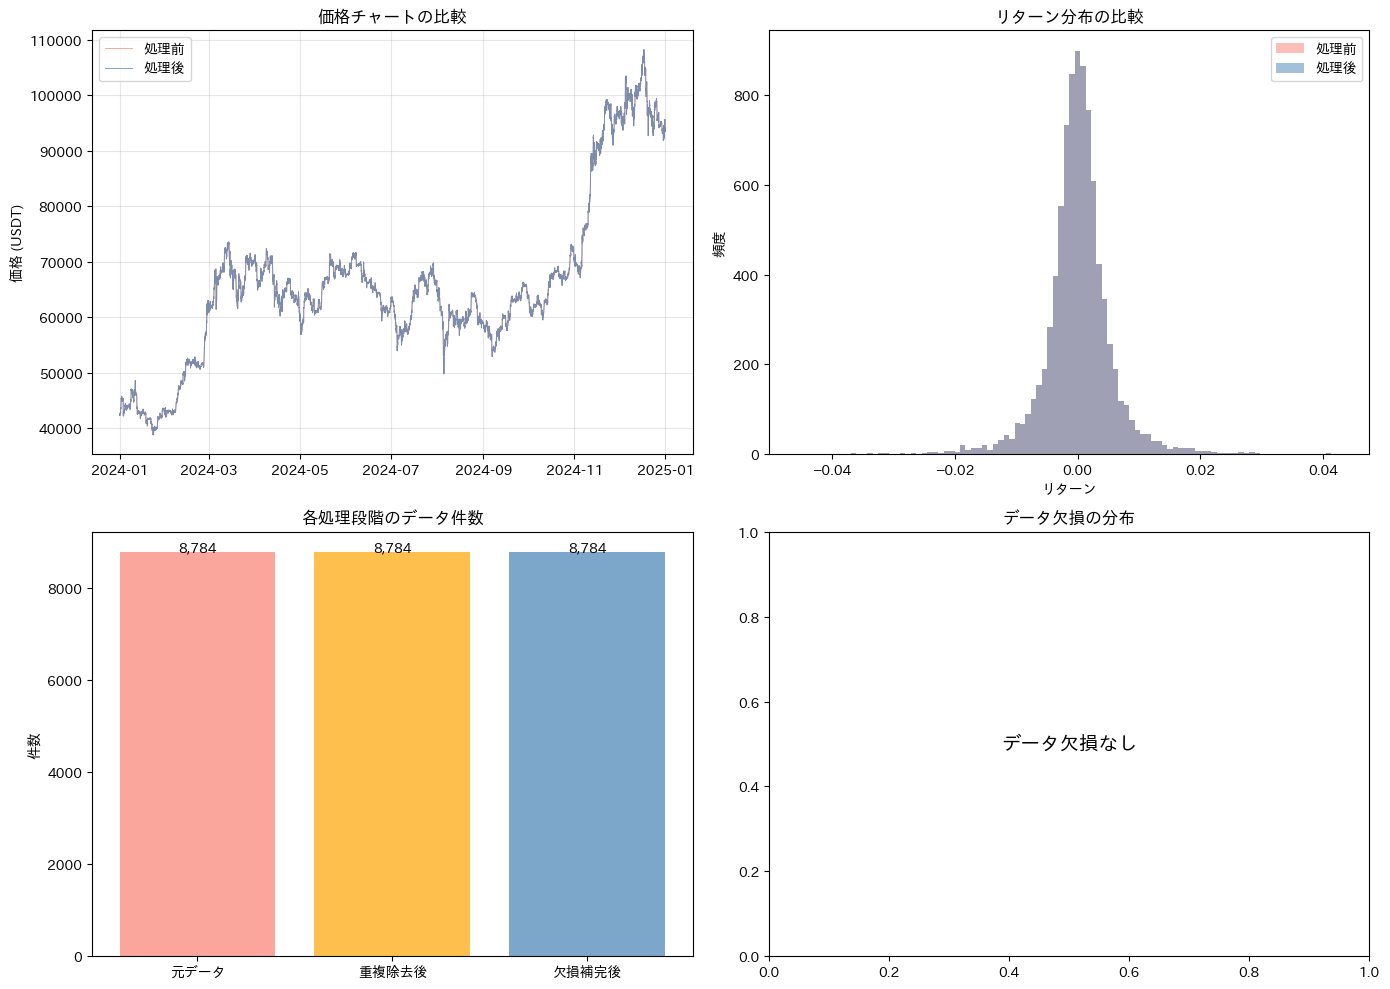

In [ ]:
# クレンジング前のデータにもリターンを計算
df_raw['ret'] = df_raw['close'].pct_change()

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# (1) 価格チャートの比較
axes[0, 0].plot(df_raw.index, df_raw['close'], color='salmon', alpha=0.7, linewidth=0.7, label='処理前')
axes[0, 0].plot(df_1h.index, df_1h['close'], color='steelblue', alpha=0.7, linewidth=0.7, label='処理後')
axes[0, 0].set_title('価格チャートの比較')
axes[0, 0].set_ylabel('価格 (USDT)')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# (2) リターン分布の比較
axes[0, 1].hist(df_raw['ret'].dropna(), bins=100, alpha=0.5, color='salmon', label='処理前')
axes[0, 1].hist(df_1h['ret'].dropna(), bins=100, alpha=0.5, color='steelblue', label='処理後')
axes[0, 1].set_title('リターン分布の比較')
axes[0, 1].set_xlabel('リターン')
axes[0, 1].set_ylabel('頻度')
axes[0, 1].legend()

# (3) 各処理段階のデータ件数
labels = ['元データ', '重複除去後', '欠損補完後']
n_after_dedup = len(df_raw) - n_duplicates
counts = [len(df_raw), n_after_dedup, len(df_1h)]
colors = ['salmon', 'orange', 'steelblue']
bars = axes[1, 0].bar(labels, counts, color=colors, alpha=0.7)
axes[1, 0].set_title('各処理段階のデータ件数')
axes[1, 0].set_ylabel('件数')
for bar, v in zip(bars, counts):
    axes[1, 0].text(bar.get_x() + bar.get_width() / 2, v + 20,
                     f'{v:,}', ha='center', fontsize=10)

# (4) 欠損箇所の可視化
if n_missing > 0:
    raw_index_series = pd.Series(df_raw.index)
    time_diffs = raw_index_series.diff()
    expected_diff = pd.Timedelta('1h')
    gaps = time_diffs[time_diffs > expected_diff]

    if len(gaps) > 0:
        gap_hours = (gaps / expected_diff).astype(int) - 1
        axes[1, 1].bar(range(len(gap_hours)), gap_hours.values, color='salmon', alpha=0.7)
        axes[1, 1].set_title(f'データ欠損の分布（{len(gaps)} 箇所, 計 {n_missing} 本）')
        axes[1, 1].set_xlabel('欠損箇所（発生順）')
        axes[1, 1].set_ylabel('欠損本数（時間）')
    else:
        axes[1, 1].text(0.5, 0.5, '連続欠損なし', ha='center', va='center',
                         transform=axes[1, 1].transAxes, fontsize=14)
        axes[1, 1].set_title('データ欠損の分布')
else:
    axes[1, 1].text(0.5, 0.5, 'データ欠損なし', ha='center', va='center',
                     transform=axes[1, 1].transAxes, fontsize=14)
    axes[1, 1].set_title('データ欠損の分布')

plt.tight_layout()
plt.show()

## 9. クレンジング済みデータの最終確認

In [ ]:
# 最終的なデータの状態
print("=" * 60)
print("クレンジング済みデータの概要")
print("=" * 60)
print(f"銘柄:   {symbol}")
print(f"時間足: {timeframe}")
print(f"期間:   {df_1h.index.min()} 〜 {df_1h.index.max()}")
print(f"データ数: {len(df_1h):,}")
print(f"欠損値:   {df_1h[['open', 'high', 'low', 'close', 'volume']].isnull().sum().sum()}")
print(f"重複行:   {df_1h.index.duplicated().sum()}")
print()

# 処理サマリ
print("--- 処理サマリ ---")
print(f"重複除去:     {n_duplicates} 行")
print(f"欠損補完:     {n_missing} 行（ffill）")
print(f"異常値除去:   {n_removed} 件（価格異常・極端な変動・OHLC不整合）")
print()

# 最終データの先頭表示
print("--- 最終データ（先頭5行）---")
df_1h[['open', 'high', 'low', 'close', 'volume', 'ret']].head()

クレンジング済みデータの概要
銘柄:   BTCUSDT
時間足: 1h
期間:   2024-01-01 00:00:00+00:00 〜 2024-12-31 23:00:00+00:00
データ数: 8,784
欠損値:   0
重複行:   0

--- 処理サマリ ---
重複除去:     0 行
欠損補完:     0 行（ffill）
異常値除去:   0 件（価格異常・極端な変動・OHLC不整合）

--- 最終データ（先頭5行）---


,open,high,low,close,volume,ret
timestamp,,,,,,
2024-01-01 00:00:00+00:00,42283.58,42554.57,42261.02,42475.23,1271.68108,NaN
2024-01-01 01:00:00+00:00,42475.23,42775.00,42431.65,42613.56,1196.37856,0.003257
2024-01-01 02:00:00+00:00,42613.57,42638.41,42500.00,42581.10,685.21980,-0.000762
2024-01-01 03:00:00+00:00,42581.09,42586.64,42230.08,42330.49,794.80391,-0.005885
2024-01-01 04:00:00+00:00,42330.50,42399.99,42209.46,42399.99,715.41760,0.001642


## 10. まとめ

このnotebookでは、データ分析の最初のステップである **データ取得とクレンジング** を学びました。

### 学んだこと

| ステップ | 内容 | ポイント |
|---------|------|---------|
| データ取得 | Binance REST APIからOHLCVを取得 | ページネーションで上限を超えるデータも取得可能 |
| DataFrame変換 | 型変換、インデックス設定 | `set_index` + `sort_index` が基本 |
| 重複除去 | `duplicated()` で検出 → `keep='first'` で除去 | API取得時の境界重複に注意 |
| 欠損補完 | 完全インデックスで `reindex` → `ffill` で補完 | 前方補完でリークを防ぐ |
| リターン計算 | `pct_change()` でリターンを計算 | cumsumで累積リターンを計算 |
| 異常値処理 | 価格妥当性・変動率・出来高の3観点でチェック | 統計的閾値ではなくドメイン知識で判断 |

### 異常値処理の考え方（重要）

- Zスコア法やIQR法は汎用的だが、**暗号資産のファットテール分布には不向き**
- 市場の急変動（テールイベント）は正常な価格形成の一部であり、除去してはいけない
- 除去すべきは **取引所の障害やデータ欠損に起因する明らかなノイズ** のみ
- 迷ったら残す。データの安易な削除はリスクの過小評価につながる

### 次のステップ

**Vol.02: リターン分布と出来高分布** では、ここで計算したリターンの統計的な性質をより詳しく分析します。
正規分布との違い、ファットテールの存在、出来高との関係などを掘り下げます。

## 分析結果から分かったこと

### データ品質
- BTC/USDT 1時間足（2024年1年間）のデータは **8,784本** で、**重複・欠損ともにゼロ**だった
- Binanceは主要ペアについては非常に高品質なデータを提供しており、今回はクレンジング処理の実質的な出番がなかった
- ただし、マイナー銘柄や他の取引所ではデータ品質が低いこともあるため、チェック手順自体は常に行うべき

### リターンの特性
- 1時間あたりの平均リターンは約 **+0.01%**（わずかにプラス）。2024年はBTCが上昇トレンドだったことを反映
- 標準偏差は約 **0.56%** で、1時間で±0.56%程度の変動が日常的に起きている
- 最大で1時間に数%の急変動があるが、これはBTC市場では正常な範囲

### 異常値の考え方
- 今回のデータでは、価格異常（ゼロ・負値）、50%超の変動、OHLC不整合はいずれもゼロ件だった
- 数%程度の大きな変動は多数あるが、これらは市場のテールイベントであり除去すべきではない
- **「統計的に外れ値」と「データ異常」は別の概念**。暗号資産分析では、Zスコアやクリッピングによる機械的なフィルタリングは避け、取引所障害やデータ欠損のみを対象とすべき


## 留意事項
* このnotebookは学習・検証を目的とした教育資料として公開しており、投資助言または投資勧誘を目的とするものではありません。
* 本notebookの著作権は作成者である[ほへとさん](https://x.com/i_love_profit)に帰属します。
* 公開者となるビットバンク株式会社は本notebookの内容の監修・保証（正確性・完全性・安全性）を行いません。
* 実行・利用は、必ず利用者自身の判断と責任で行ってください。